## 第一题
1. 
先计算精确解：
$$I = \int_{[0,1]^d} e^{-\sum_{i=1}^d x_i} dx$$
$$I = \int_0^1 e^{-x_1} dx_1 \cdot \int_0^1 e^{-x_2} dx_2 \cdots \int_0^1 e^{-x_d} dx_d$$
$$\int_0^1 e^{-x} dx = \left[ -e^{-x} \right]_0^1 = (-e^{-1}) - (-e^0) = -e^{-1} + 1 = 1 - \frac{1}{e}$$
$$I = \left( 1 - \frac{1}{e} \right)^d$$
复合梯形：
$$\int_0^1 f(x)dx \approx \frac{h}{2} \left[ f(x_0) + 2\sum_{i=1}^{n-1}f(x_i) + f(x_n) \right]$$
中矩形公式：


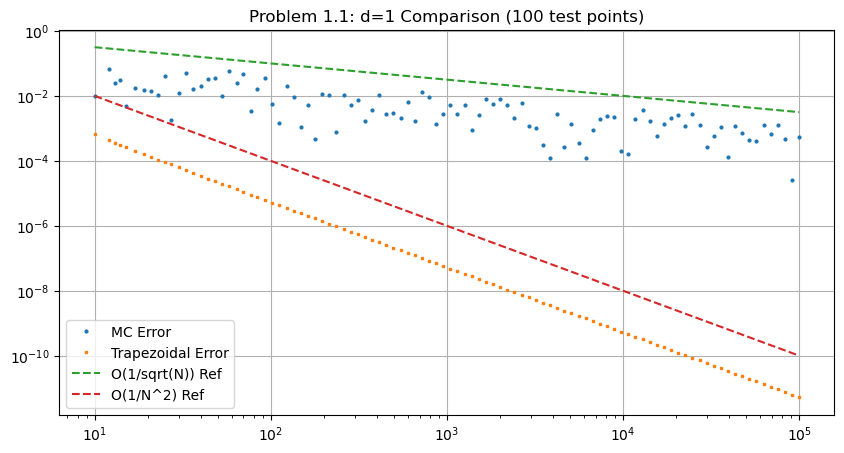

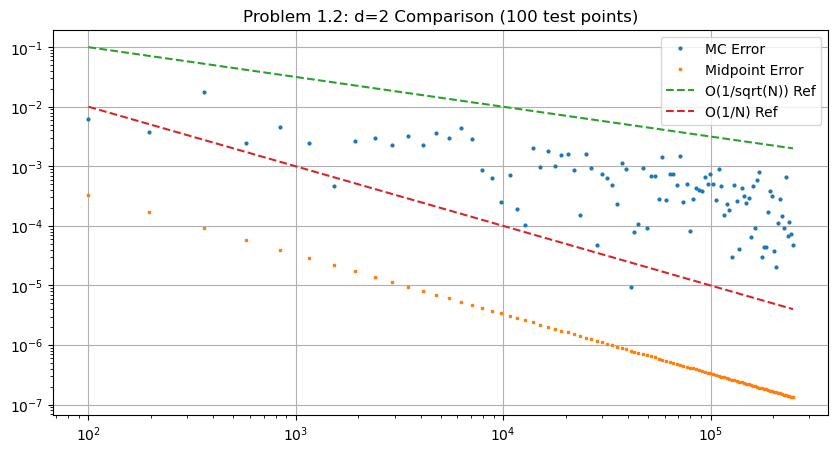

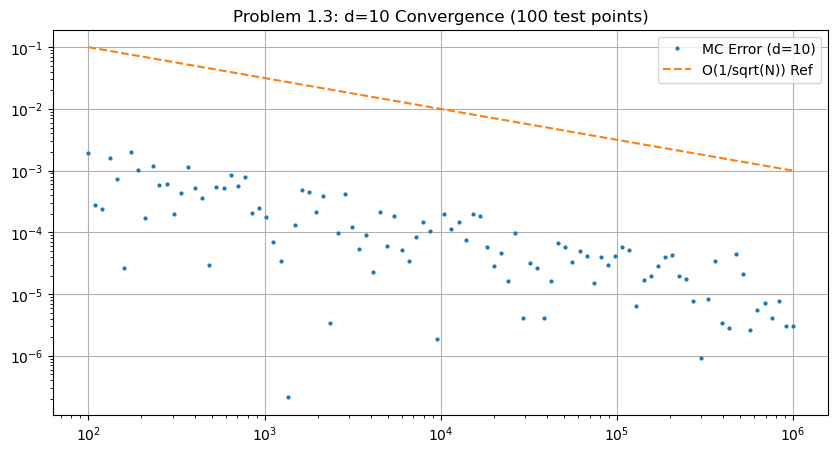

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机数种子
np.random.seed(42)

def f_d(x):
    """待积分函数: e^(-sum(x_i))"""
    return np.exp(-np.sum(x, axis=1))

def exact_solution(d):
    """理论精确解"""
    return (1 - np.exp(-1))**d

# --- 1.1 d=1 情形 ---
def monte_carlo_1d(N):
    x = np.random.uniform(0, 1, (N, 1))
    return np.mean(np.exp(-x))

def trapezoidal_1d(N):
    x = np.linspace(0, 1, N)
    y = np.exp(-x)
    return (y[0] + y[-1] + 2 * np.sum(y[1:-1])) / (2 * (N - 1))

# 取100个测试点
N_list_1d = np.unique(np.logspace(1, 5, 100).astype(int))
exact_1d = exact_solution(1)
mc_errs_1d, trap_errs_1d = [], []

for N in N_list_1d:
    mc_errs_1d.append(abs(monte_carlo_1d(N) - exact_1d))
    trap_errs_1d.append(abs(trapezoidal_1d(N) - exact_1d))

plt.figure(figsize=(10, 5))
plt.loglog(N_list_1d, mc_errs_1d, 'o', markersize=2, label='MC Error')
plt.loglog(N_list_1d, trap_errs_1d, 's', markersize=2, label='Trapezoidal Error')
plt.loglog(N_list_1d, 1/np.sqrt(N_list_1d), '--', label='O(1/sqrt(N)) Ref')
plt.loglog(N_list_1d, 1/N_list_1d**2, '--', label='O(1/N^2) Ref')
plt.title('Problem 1.1: d=1 Comparison (100 test points)')
plt.legend(); plt.grid(True); plt.show()

# --- 1.2 d=2 情形 ---
def midpoint_2d(M):
    h = 1.0 / M
    c = np.linspace(h/2, 1-h/2, M)
    x, y = np.meshgrid(c, c)
    return np.mean(np.exp(-(x + y)))

# 取100个不同的M，对应100个N = M^2
M_list = np.unique(np.linspace(10, 500, 100).astype(int))
N_list_2d = M_list**2
exact_2d = exact_solution(2)
mc_errs_2d, mid_errs_2d = [], []

for M in M_list:
    N = M**2
    mc_errs_2d.append(abs(np.mean(f_d(np.random.uniform(0,1,(N,2)))) - exact_2d))
    mid_errs_2d.append(abs(midpoint_2d(M) - exact_2d))

plt.figure(figsize=(10, 5))
plt.loglog(N_list_2d, mc_errs_2d, 'o', markersize=2, label='MC Error')
plt.loglog(N_list_2d, mid_errs_2d, 's', markersize=2, label='Midpoint Error')
plt.loglog(N_list_2d, 1/np.sqrt(N_list_2d), '--', label='O(1/sqrt(N)) Ref')
plt.loglog(N_list_2d, 1/N_list_2d, '--', label='O(1/N) Ref')
plt.title('Problem 1.2: d=2 Comparison (100 test points)')
plt.legend(); plt.grid(True); plt.show()

# --- 1.3 d=10 情形 ---
N_list_10 = np.unique(np.logspace(2, 6, 100).astype(int))
exact_10 = exact_solution(10)
mc_errs_10 = []

for N in N_list_10:
    mc_errs_10.append(abs(np.mean(f_d(np.random.uniform(0,1,(N,10)))) - exact_10))

plt.figure(figsize=(10, 5))
plt.loglog(N_list_10, mc_errs_10, 'o', markersize=2, label='MC Error (d=10)')
plt.loglog(N_list_10, 1/np.sqrt(N_list_10), '--', label='O(1/sqrt(N)) Ref')
plt.title('Problem 1.3: d=10 Convergence (100 test points)')
plt.legend(); plt.grid(True); plt.show()

可以观察到，d=1时，复合梯形公式呈现标准的2阶收敛，而MonteCarlo方法大致符合半阶收敛，复合梯形公式收敛速度比Monte Carlo方法快得多
在d=2时，中矩形公式呈现2阶收敛，MC方法大致呈现半阶收敛，但是相比一维时的情况误差更加分散
d=10时，MC方法仍然是半阶收敛，因为$$\epsilon \approx \sqrt{\text{Var}(\hat{I}_N)} = \frac{\sigma}{\sqrt{N}}$$与维数无关

## 第二题


#### 分层抽样
将区间 $[0,1]$ 等分为 $K$ 个子区间 $[j/K, (j+1)/K]$。在每个子区间内均匀抽取 $n_j$ 个点。


#### 重要性采样
*   **分布 A：$g(x) = 2(1-x), x \in [0,1]$**
    $G(x) = \int_0^x 2(1-t)dt = 2x - x^2$。
    令 $u = 2x - x^2$，解出 $x$：$(x-1)^2 = 1-u \Rightarrow x = 1 - \sqrt{1-u}$。
    $X = 1 - \sqrt{U}$。

*   **分布 B：$g(x) = \frac{e^{-x}}{1-e^{-1}}, x \in [0,1]$**
    $G(x) = \int_0^x \frac{e^{-t}}{1-e^{-1}}dt = \frac{1-e^{-x}}{1-e^{-1}}$。
    令 $u = G(x)$，解出 $x$：$e^{-x} = 1 - u(1-e^{-1}) \Rightarrow x = -\ln(1 - u(1-e^{-1}))$。
    $X = -\ln(1 - U \cdot (1-e^{-1}))$。

In [17]:
# 分层
def stratified_sampling(N, K=10):
    n_per_strata = max(1, N // K)
    estimates = []
    for k in range(K):
        x = np.random.uniform(k/K, (k+1)/K, n_per_strata)
        estimates.append(np.mean(np.exp(-x)))
    return np.mean(estimates)

#固定 N，重复 100 次
N_fixed = 1000
mc_trials = [np.mean(np.exp(-np.random.uniform(0, 1, N_fixed))) for _ in range(100)]
strat_trials = [stratified_sampling(N_fixed, K=10) for _ in range(100)]

print(f"N={N_fixed}方差对比")
print(f"MC {np.var(mc_trials):.2e}")
print(f"分层抽样 {np.var(strat_trials):.2e}")

N=1000方差对比
MC 2.94e-05
分层抽样 3.33e-07


可以看到，通过进行分层抽样，方差降低了两个数量级

重要性采样的统计分布曲线和效果对比

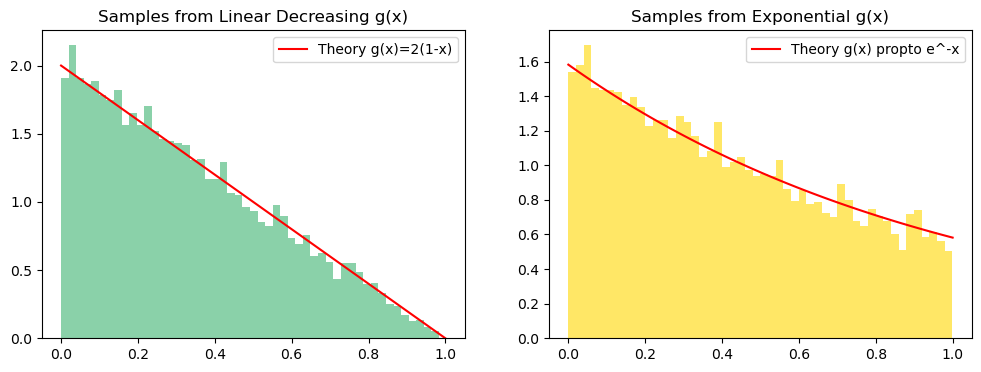

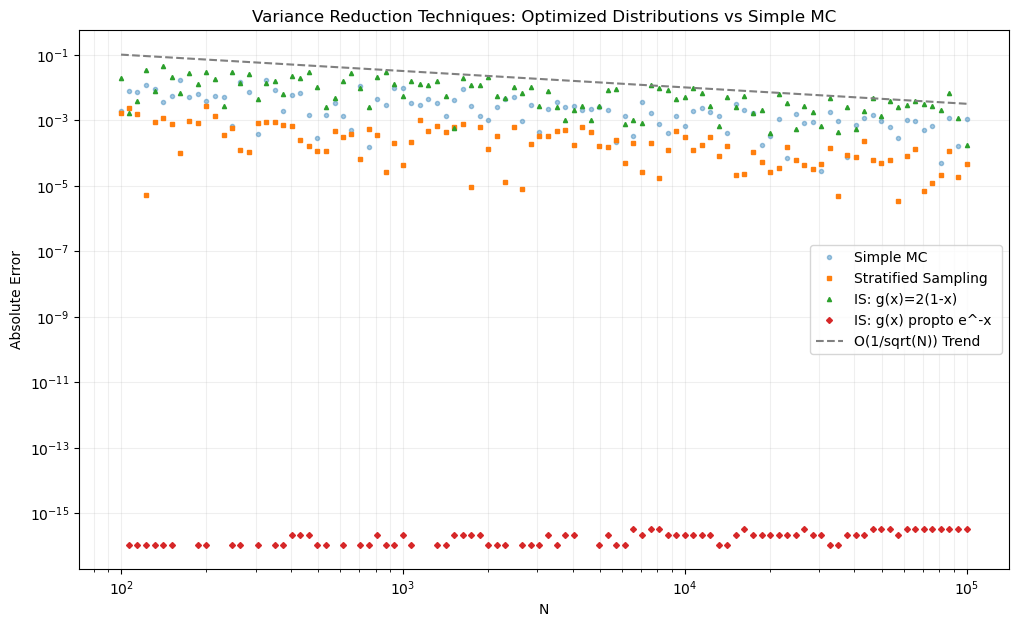

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 基础设置
np.random.seed(42)
def f(x): return np.exp(-x)
exact_val = 1 - np.exp(-1)
N_test_points = 100

def simple_monte_carlo(N):
    x = np.random.uniform(0, 1, N)
    return np.mean(f(x))

def stratified_sampling(N, K=10):
    n_per_strata = max(1, N // K)
    estimates = []
    for k in range(K):
        x = np.random.uniform(k/K, (k+1)/K, n_per_strata)
        estimates.append(np.mean(f(x)))
    return np.mean(estimates)

def importance_sampling_C(N):
    u = np.random.uniform(0, 1, N)
    x = 1 - np.sqrt(1 - u) 
    g_x = 2 * (1 - x)
    return np.mean(f(x) / g_x)

def importance_sampling_D(N):
    u = np.random.uniform(0, 1, N)
    const = 1 - np.exp(-1)
    x = -np.log(1 - u * const)
    g_x = np.exp(-x) / const
    return np.mean(f(x) / g_x)

u_test = np.random.uniform(0, 1, 10000)
x_C = 1 - np.sqrt(1 - u_test)
x_D = -np.log(1 - u_test * (1 - np.exp(-1)))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(x_C, bins=50, density=True, alpha=0.6, color='mediumseagreen')
plt.plot(np.linspace(0,1,100), 2*(1-np.linspace(0,1,100)), 'r-', label='Theory g(x)=2(1-x)')
plt.title('Samples from Linear Decreasing g(x)'); plt.legend()

plt.subplot(1, 2, 2)
plt.hist(x_D, bins=50, density=True, alpha=0.6, color='gold')
xr = np.linspace(0,1,100)
plt.plot(xr, np.exp(-xr)/(1-np.exp(-1)), 'r-', label='Theory g(x) propto e^-x')
plt.title('Samples from Exponential g(x)'); plt.legend()
plt.show()

N_list = np.unique(np.logspace(2, 5, N_test_points).astype(int))
err_mc, err_strat, err_is_C, err_is_D = [], [], [], []

for N in N_list:
    err_mc.append(abs(simple_monte_carlo(N) - exact_val))
    err_strat.append(abs(stratified_sampling(N) - exact_val))
    err_is_C.append(abs(importance_sampling_C(N) - exact_val))
    err_is_D.append(abs(importance_sampling_D(N) - exact_val))

plt.figure(figsize=(12, 7))
plt.loglog(N_list, err_mc, 'o', markersize=3, alpha=0.4, label='Simple MC ')
plt.loglog(N_list, err_strat, 's', markersize=3, label='Stratified Sampling')
plt.loglog(N_list, err_is_C, '^', markersize=3, label='IS: g(x)=2(1-x) ')
plt.loglog(N_list, err_is_D, 'D', markersize=3, label='IS: g(x) propto e^-x ')

# 参考线
plt.loglog(N_list, 1/np.sqrt(N_list), '--', color='gray', label='O(1/sqrt(N)) Trend')

plt.title('Variance Reduction Techniques: Optimized Distributions vs Simple MC')
plt.xlabel('N'); plt.ylabel('Absolute Error'); plt.legend(); plt.grid(True, which="both", alpha=0.2)
plt.show()

可以看到，通过逆变换公式进行的随机采样接近服从给定分布的随机采样。
通过选取分布函数，(e^{-x})方差大大减小，积分结果更加精准，但是选取2(1-x)反而使得方差增大，结果更差。